<a href="https://colab.research.google.com/github/TetianaMar-888/Amazon_Books_project/blob/main/notebooks/DM1_02_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Clustering
### Board Games Dataset

This notebook covers:
1. Feature selection for clustering
2. Centroid-based clustering (K-Means, mandatory)
3. Density-based clustering (DBSCAN, mandatory)
4. Hierarchical clustering (dendrogram analysis)
5. Final comparison & discussion — best algorithm for this dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_clean = pd.read_parquet('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/data/board_games_cleaned.parquet')
print(data_clean.shape)

Mounted at /content/drive
(21181, 39)


## 1. Feature Selection for Clustering

In [ ]:
clustering_features = [
    "ComWeight", "MinPlayers", "MaxPlayers", "ComAgeRec",
    "NumOwned_log", "NumUserRatings_log", "MfgPlaytime_log"
]

print("Missing values in the selected features:")
print(data_clean[clustering_features].isna().sum())

data_cluster = data_clean[clustering_features].dropna()

lost = len(data_clean) - len(data_cluster)
print(f"\nRows: {len(data_clean)} -> {len(data_cluster)}  "
      f"({lost} dropped listwise, {lost/len(data_clean)*100:.1f}%)")

Missing values in the selected features:
ComWeight              461
MinPlayers               0
MaxPlayers               0
ComAgeRec             5277
NumOwned_log             0
NumUserRatings_log       0
MfgPlaytime_log        666
dtype: int64

Rows: 21181 -> 15487  (5694 dropped listwise, 26.9%)


### Feature selection and the cost of listwise deletion

Seven variables were selected for clustering, covering the three dimensions the
correlation analysis of Module 1 identified as largely independent: complexity
(`ComWeight`, `ComAgeRec`), format (`MinPlayers`, `MaxPlayers`, `MfgPlaytime_log`)
and popularity (`NumOwned_log`, `NumUserRatings_log`).

Both members of the popularity block are retained despite correlating at 0.95.
Reducing them to one would be defensible on redundancy grounds, but distances
here are computed on standardised features, where each variable contributes
equally to the total distance. Dropping one would therefore halve the weight the
popularity dimension carries relative to complexity, which is represented by two
variables, and format, which is represented by three. Keeping both preserves the
balance between the three axes, which matters more for a distance-based method
than the redundancy costs.

Listwise deletion reduces the dataset from 21,181 to 15,487 games (26.9%). The
loss is dominated by `ComAgeRec` (5,277 missing), with `MfgPlaytime_log` (666)
and `ComWeight` (461) contributing the remainder. These do not simply add up:
the three columns are missing for 6,404 records in total, yet only 5,694 records
are removed, meaning 710 games lack values in more than one column at once. The
missingness is therefore concentrated rather than spread — it is the same group
of older, rarely-voted-on games that the community has assessed on no dimension
at all.

Imputation was rejected for this reason. The missingness is not random (MNAR):
filling `ComAgeRec` with its median would place precisely those unassessed games
at the centre of the age distribution, creating an artificial dense region of
5,277 near-identical points. K-Means would absorb it into a centroid and DBSCAN
would report it as a spurious high-density cluster — in both cases describing the
imputation rule rather than the games. Listwise deletion sacrifices sample size
but leaves the remaining structure undistorted, which matters more for an
unsupervised task, where there is no held-out metric that would expose such an
artefact.

## 2. Centroid-based Clustering — K-Means

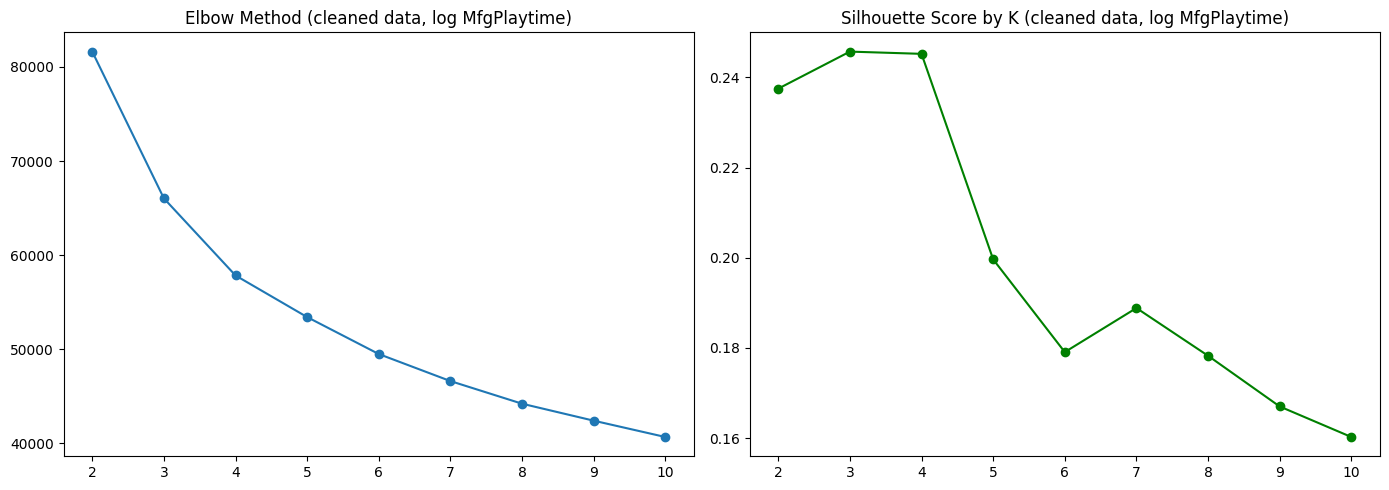

Silhouette scores: {2: np.float64(0.23751839431507069), 3: np.float64(0.2457362339597418), 4: np.float64(0.24523938220481487), 5: np.float64(0.1996542319969388), 6: np.float64(0.17908733708082084), 7: np.float64(0.18886092439548102), 8: np.float64(0.17827185053441102), 9: np.float64(0.1670246045308624), 10: np.float64(0.16025349208920361)}


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_cluster)

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker="o")
axes[0].set_title("Elbow Method (cleaned data, log MfgPlaytime)")
axes[1].plot(K_range, silhouettes, marker="o", color="green")
axes[1].set_title("Silhouette Score by K (cleaned data, log MfgPlaytime)")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/kmeans_k_selection_v3.png', dpi=150)
plt.show()

print("Silhouette scores:", dict(zip(K_range, silhouettes)))

In [ ]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(X_scaled)
    sizes = np.bincount(lab)
    print(f"\n--- K={k} ---")
    print("sizes:              ", sizes, f"(smallest = {sizes.min()/len(lab)*100:.1f}%)")
    print("silhouette:         ", round(silhouette_score(X_scaled, lab), 4))
    print("Calinski-Harabasz:  ", round(calinski_harabasz_score(X_scaled, lab), 1))
    print("Davies-Bouldin:     ", round(davies_bouldin_score(X_scaled, lab), 4))

    prof = pd.DataFrame(X_scaled, columns=clustering_features).assign(c=lab).groupby("c").mean()
    print(prof.round(2))


--- K=3 ---
sizes:               [4114 4347 7026] (smallest = 26.6%)
silhouette:          0.2457
Calinski-Harabasz:   4966.7
Davies-Bouldin:      1.3219
   ComWeight  MinPlayers  MaxPlayers  ComAgeRec  NumOwned_log  \
c                                                               
0       0.14       -0.03        0.10       0.00          1.26   
1       0.99       -0.29       -0.42       1.01         -0.31   
2      -0.69        0.19        0.20      -0.63         -0.55   

   NumUserRatings_log  MfgPlaytime_log  
c                                       
0                1.30             0.03  
1               -0.45             1.00  
2               -0.49            -0.63  

--- K=4 ---
sizes:               [5778 1899 4049 3761] (smallest = 12.3%)
silhouette:          0.2452
Calinski-Harabasz:   4510.9
Davies-Bouldin:      1.3838
   ComWeight  MinPlayers  MaxPlayers  ComAgeRec  NumOwned_log  \
c                                                               
0      -0.68       -0.17  

### K-Means: choosing K

Silhouette scores were computed for K = 2…10, and the two leading candidates
evaluated against two further internal indices:

| K | Silhouette ↑ | Calinski-Harabasz ↑ | Davies-Bouldin ↓ | Smallest cluster |
|---|---|---|---|---|
| 3 | **0.2457** | **4966.7** | **1.3219** | 26.6% |
| 4 | 0.2452 | 4510.9 | 1.3838 | 12.3% |

All three indices favour K=3, but by margins small enough to be uninformative —
the silhouette difference is 0.0005. Calinski-Harabasz in particular penalises
additional clusters by construction, so its decline at K=4 is expected rather
than evidence against the partition.

**K=4 was selected**, on interpretability grounds, and the reasoning is worth
stating explicitly since it runs against the metrics. The standardised cluster
profiles show that the K=3 solution separates games along two axes only,
popularity and complexity, while player count is essentially flat across all
three clusters (standardised `MinPlayers` means of -0.03, -0.29 and +0.19). The
format dimension is not represented at all. K=4 recovers it: the additional
cluster contains 1,899 games (12.3%) with `MinPlayers` at +1.61 and `MaxPlayers`
at +1.41 standard deviations — party games for large groups, a well-established
category in the domain. This cluster is not a subdivision of an existing group
along the same axis; it splits off from the simple-games cluster along a
dimension the K=3 solution ignores entirely.

Choosing K=3 would yield a marginally tighter partition that describes the
dataset less completely. Since the purpose of this analysis is to characterise
the kinds of board games the data contains rather than to optimise a separation
score, the additional structure is worth the negligible metric cost.

Silhouette values in the 0.20–0.25 range indicate moderate rather than strong
separation. This is consistent with the nature of the data: complexity, playtime
and popularity are continuous attributes with no natural breakpoints, so the
clusters describe regions of a continuum rather than discrete, well-isolated
groups. The K=6 peak observed before cleaning (0.282) was higher only because
outliers had been isolated into degenerate clusters.

### K-Means: Choosing K — initial attempt (before outlier cleaning)

⚠️ An initial run of this module, before the outlier and sentinel cleaning
described in Module 1, showed a silhouette peak at K=6 (0.282). Inspecting the
resulting partition revealed two degenerate clusters containing a handful of
games each, driven entirely by extreme values (MaxPlayers = 999,
MfgPlaytime = 60,000 minutes). The higher silhouette was therefore an artefact:
isolating outliers into their own clusters trivially increases separation without
describing any structure in the data. This finding motivated the cleaning applied
in Module 1, and the configuration reported below is the result of re-running
the analysis on the corrected data.

Cluster sizes:
            n     %
cluster            
0        5778  37.3
1        1899  12.3
2        4049  26.1
3        3761  24.3

Profiles (original units):
         ComWeight  MinPlayers  MaxPlayers  ComAgeRec  NumOwned_log  \
cluster                                                               
0             1.74        1.87        4.36       7.60          5.57   
1             1.83        3.00        7.86      10.21          6.07   
2             3.11        1.76        3.53      13.35          5.91   
3             2.47        1.85        4.56      10.08          8.17   

         NumUserRatings_log  MfgPlaytime_log  
cluster                                       
0                      4.82             3.34  
1                      5.32             3.72  
2                      4.87             4.93  
3                      7.57             4.04  

Profiles (standardised):
         ComWeight  MinPlayers  MaxPlayers  ComAgeRec  NumOwned_log  \
cluster                        

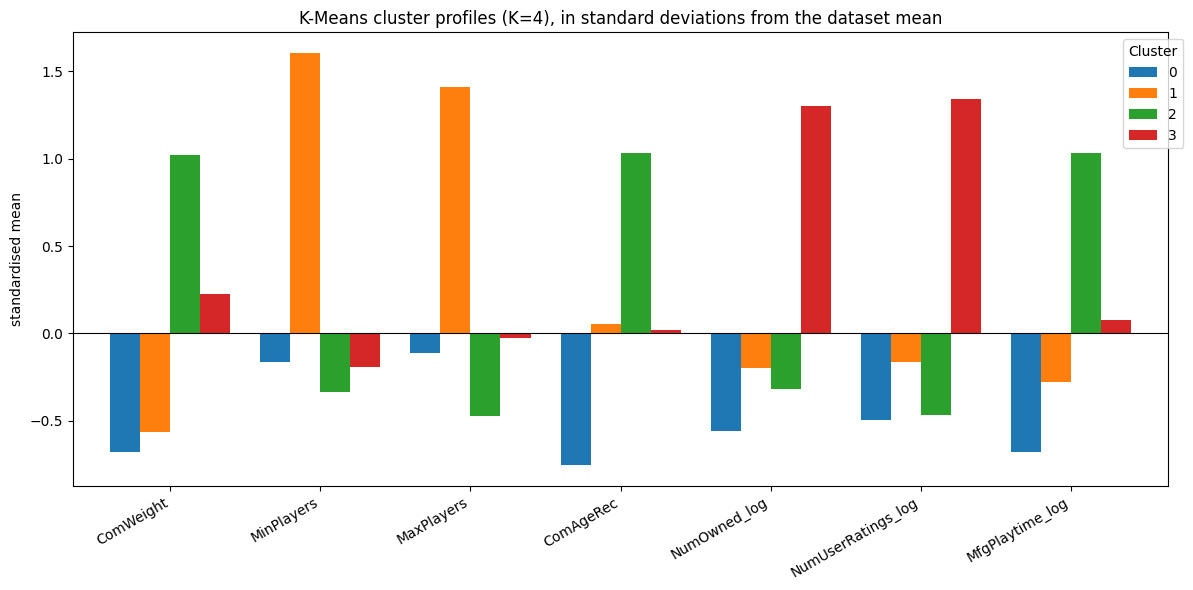

In [ ]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

data_cluster_result = data_cluster.copy()
data_cluster_result["cluster"] = cluster_labels

sizes = data_cluster_result["cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(pd.DataFrame({"n": sizes, "%": (sizes / len(data_cluster_result) * 100).round(1)}))

# Profiles in original units — for interpretation and for the report table
print("\nProfiles (original units):")
print(data_cluster_result.groupby("cluster").mean().round(2))

# Profiles in standard deviations from the overall mean — for the plot.
# Taken from X_scaled, which is standardised over all 15,487 games, so +1.6 means
# "1.6 SD above the dataset average", not "above the average of the four centroids".
profile_std = (pd.DataFrame(X_scaled, columns=clustering_features)
                 .assign(cluster=cluster_labels)
                 .groupby("cluster").mean())
print("\nProfiles (standardised):")
print(profile_std.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
profile_std.T.plot(kind="bar", ax=ax, width=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("K-Means cluster profiles (K=4), in standard deviations from the dataset mean")
ax.set_ylabel("standardised mean")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/kmeans_final_k4_profiles.png', dpi=150)
plt.show()

Figure X. K-Means cluster profiles (K=4), expressed in standard deviations from
the dataset mean. Cluster 0 = casual short games, 1 = party games,
2 = hobbyist strategy games, 3 = mainstream hits.

### K-Means: cluster interpretation (K=4)

| # | Label | Size | ComWeight | ComAgeRec | Players | Playtime | Popularity |
|---|---|---|---|---|---|---|---|
| 0 | Casual short games | 5,778 (37.3%) | 1.74 | 7.6 | 2–4 | lowest | low |
| 1 | Party games | 1,899 (12.3%) | 1.83 | 10.2 | 3–8 | low | low |
| 2 | Hobbyist strategy games | 4,049 (26.1%) | 3.11 | 13.4 | 2–4 | highest | low |
| 3 | Mainstream hits | 3,761 (24.3%) | 2.47 | 10.1 | 2–5 | medium | highest |

**Cluster 0 — casual short games** is the largest group and sits below the
dataset mean on every dimension except player count. The defining combination is
the lowest complexity (1.74) paired with the youngest recommended age (7.6 years)
and the shortest playtime: children's games and light family titles.

**Cluster 1 — party games** is the group the K=3 solution failed to isolate. Its
complexity is as low as cluster 0's (1.83), but it supports 3 to 8 players
against 2 to 4, and targets a noticeably older audience (10.2 versus 7.6 years).
Low difficulty for a large adult group is precisely the party-game formula, and
the separation is driven almost entirely by the two player-count variables
(+1.61 and +1.41 standard deviations).

**Cluster 2 — hobbyist strategy games** is the opposite pole of cluster 0:
highest complexity (3.11), oldest recommended age (13.4), longest playtime
(+1.03 SD), smallest player counts. These are the demanding titles played by
enthusiasts in pairs or small groups.

**Cluster 3 — mainstream hits** is defined by popularity rather than by any
design attribute. Its `NumUserRatings_log` of 7.57 stands more than 1.3 standard
deviations above the mean, while the other three clusters sit between 4.82 and
5.32 — a gap of roughly an order of magnitude in raw rating counts. On complexity
(2.47) and playtime it is unremarkable, occupying the middle of the range. This
is the informative part: the games the community has actually adopted at scale
are not the most complex nor the simplest, but those of moderate difficulty and
duration. Accessibility appears to be a stronger driver of adoption than
sophistication.

The four clusters recover the three axes identified as independent in the
Module 1 correlation analysis — complexity, format and popularity — and map onto
categories a domain expert would recognise without having seen the algorithm's
output. Given the modest silhouette values, this correspondence is the stronger
evidence that the partition reflects genuine structure: a solution that separates
cleanly but resists interpretation would be far less convincing.

## 3. Density-based Clustering — DBSCAN

Knee at index 14724 of 15487  ->  suggested eps ≈ 1.256
Points with 10-NN distance above the knee: 762 (4.9%)


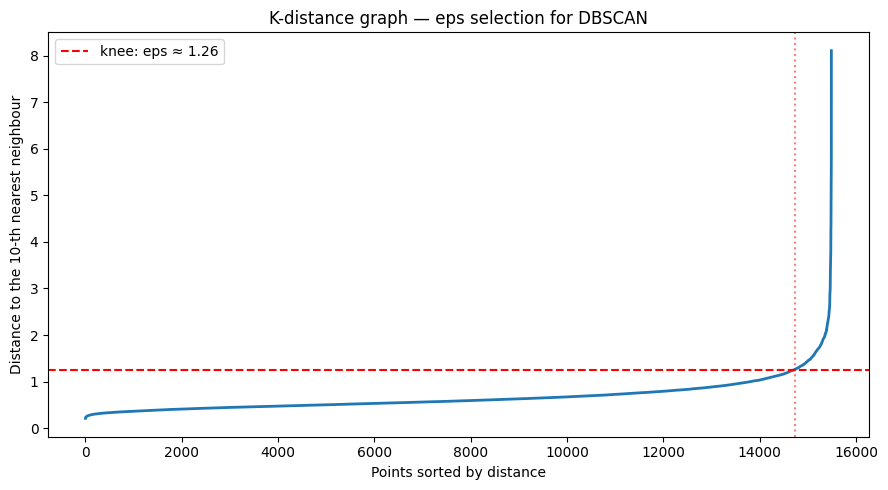

In [ ]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 10   # must match the min_samples passed to DBSCAN

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
d = np.sort(distances[:, -1])
x = np.arange(len(d))

# Knee = the point at maximum perpendicular distance from the chord joining
# the first and last point of the curve.
x1, y1, x2, y2 = x[0], d[0], x[-1], d[-1]
dist_to_chord = np.abs((y2 - y1) * x - (x2 - x1) * d + x2 * y1 - y2 * x1) / np.hypot(y2 - y1, x2 - x1)
knee = int(np.argmax(dist_to_chord))
eps_suggested = d[knee]
print(f"Knee at index {knee} of {len(d)}  ->  suggested eps ≈ {eps_suggested:.3f}")
print(f"Points with {MIN_SAMPLES}-NN distance above the knee: "
      f"{(d > eps_suggested).sum()} ({(d > eps_suggested).mean()*100:.1f}%)")

plt.figure(figsize=(9, 5))
plt.plot(x, d, lw=2)
plt.axhline(eps_suggested, color="red", ls="--", label=f"knee: eps ≈ {eps_suggested:.2f}")
plt.axvline(knee, color="red", ls=":", alpha=0.5)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to the {MIN_SAMPLES}-th nearest neighbour")
plt.title("K-distance graph — eps selection for DBSCAN")
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/dbscan_kdistance.png', dpi=150)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

# Grid centred on the knee estimate (1.256), extended in both directions
eps_values = [0.6, 0.8, 1.0, 1.2, 1.26, 1.4, 1.6]
min_samples_values = [5, 10, 20]

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean() * 100

        # Silhouette on non-noise points only; undefined with fewer than 2 clusters
        mask = labels != -1
        sil = (silhouette_score(X_scaled[mask], labels[mask])
               if n_clusters >= 2 and mask.sum() > 0 else np.nan)

        # Share of non-noise points falling in the single largest cluster —
        # exposes the degenerate case of "one giant blob plus fragments"
        if n_clusters >= 1:
            largest = pd.Series(labels[mask]).value_counts().iloc[0] / mask.sum() * 100
        else:
            largest = np.nan

        results.append({"eps": eps, "min_samples": min_samples,
                        "n_clusters": n_clusters, "noise_%": round(noise_pct, 1),
                        "largest_cluster_%": round(largest, 1),
                        "silhouette": round(sil, 3) if not np.isnan(sil) else np.nan})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 eps  min_samples  n_clusters  noise_%  largest_cluster_%  silhouette
0.60            5          38     20.3               75.3      -0.325
0.60           10          11     29.3               79.1      -0.172
0.60           20           7     45.0               89.7      -0.108
0.80            5          15      8.0               71.8      -0.029
0.80           10           6     11.6               73.4       0.040
0.80           20           3     17.3               75.4       0.098
1.00            5          12      3.6               70.4       0.062
1.00           10           5      5.3               71.1       0.073
1.00           20           3      7.7               72.2       0.101
1.20            5           8      2.0               69.8       0.092
1.20           10           5      2.7               70.2       0.095
1.20           20           4      3.9               70.7       0.091
1.26            5           7      1.6               69.8       0.087
1.26           10   

             n     %
cluster             
-1        1185   7.7
 0       10324  66.7
 1        1468   9.5
 2        2510  16.2

Profiles, original units (noise excluded):
         ComWeight  MinPlayers  MaxPlayers  ComAgeRec  NumOwned_log  \
cluster                                                               
0             2.24         2.0        4.21       9.68          6.28   
1             2.09         3.0        5.74       9.90          6.34   
2             2.55         1.0        3.85      10.82          6.62   

         NumUserRatings_log  MfgPlaytime_log  
cluster                                       
0                      5.50             3.91  
1                      5.65             3.87  
2                      5.73             4.19  

Profiles, standardised (row -1 = noise):
         ComWeight  MinPlayers  MaxPlayers  ComAgeRec  NumOwned_log  \
cluster                                                               
-1            0.05        0.89        1.64       0.46  

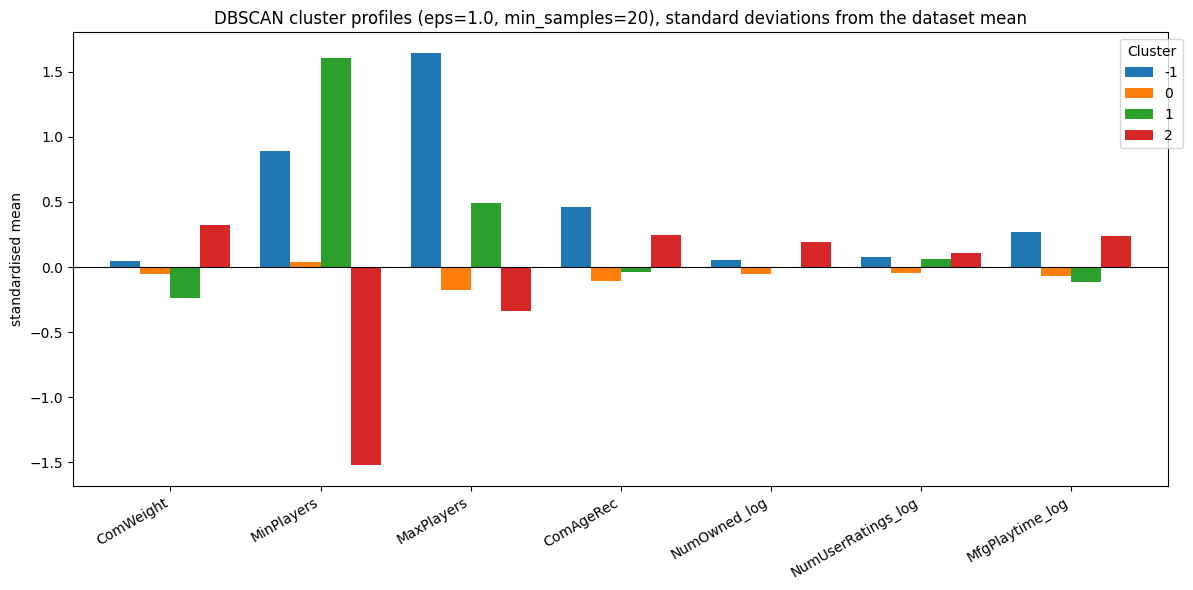

In [ ]:
EPS, MIN_SAMPLES_FINAL = 1.0, 20

final_dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES_FINAL)
dbscan_labels = final_dbscan.fit_predict(X_scaled)

data_cluster_dbscan = data_cluster.copy()
data_cluster_dbscan["cluster"] = dbscan_labels

counts = data_cluster_dbscan["cluster"].value_counts().sort_index()
print(pd.DataFrame({"n": counts, "%": (counts / len(data_cluster_dbscan) * 100).round(1)}))

print("\nProfiles, original units (noise excluded):")
print(data_cluster_dbscan[data_cluster_dbscan["cluster"] != -1]
      .groupby("cluster").mean().round(2))

# Standardised profiles, including the noise group as a comparison row
prof_db = (pd.DataFrame(X_scaled, columns=clustering_features)
             .assign(cluster=dbscan_labels)
             .groupby("cluster").mean())
print("\nProfiles, standardised (row -1 = noise):")
print(prof_db.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
prof_db.T.plot(kind="bar", ax=ax, width=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"DBSCAN cluster profiles (eps={EPS}, min_samples={MIN_SAMPLES_FINAL}), "
             f"standard deviations from the dataset mean")
ax.set_ylabel("standardised mean")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/dbscan_cluster_profiles.png', dpi=150)
plt.show()

### DBSCAN: parameter selection

A grid over eps ∈ {0.6, 0.8, 1.0, 1.2, 1.26, 1.4, 1.6} and min_samples ∈ {5, 10, 20}
was evaluated. The eps range was centred on 1.26, the knee of the k-distance graph
computed with k = min_samples = 10, and extended in both directions. Alongside
silhouette, noise percentage and cluster count, the share of non-noise points
falling in the single largest cluster was recorded — a diagnostic that turned out
to be decisive.

The highest silhouette in the entire grid, 0.523 at eps=1.6 / min_samples=5, is
an artefact and was rejected. At that configuration the largest cluster holds
99.9% of the non-noise points: the partition is one giant blob plus two fragments
of a few dozen games each, and the score is high precisely because those fragments
sit far from the mass. Selecting on silhouette alone would have produced a result
twice as good as K-Means by the numbers and entirely meaningless in substance.

Excluding the degenerate configurations, silhouette varies only between 0.09 and
0.10 across every setting with eps ≥ 1.0 — the algorithm is essentially
indifferent to its parameters on this data. **eps=1.0, min_samples=20** was
selected: it attains the highest silhouette among non-degenerate configurations
(0.101) with 3 clusters and 7.7% noise. The value of min_samples follows the
common heuristic of at least twice the dimensionality (7 features → 14), which
the original grid ceiling of 10 did not satisfy.

One figure recurs across the whole grid and is more informative than any of the
scores: the largest cluster never falls below 69.6% of non-noise points, even at
eps=0.6 where the algorithm fragments the data into 38 clusters and discards 20%
as noise. There is no parameter setting at which this dataset separates into
comparably sized dense regions.

### DBSCAN: cluster interpretation

The selected configuration yields three clusters and 1,185 noise points (7.7%).
Their profiles in original units expose what the algorithm actually found:

| Cluster | Size | MinPlayers | MaxPlayers | ComWeight | ComAgeRec | NumOwned_log |
|---|---|---|---|---|---|---|
| 0 | 10,324 (66.7%) | **2.0** | 4.21 | 2.24 | 9.68 | 6.28 |
| 1 | 1,468 (9.5%) | **3.0** | 5.74 | 2.09 | 9.90 | 6.34 |
| 2 | 2,510 (16.2%) | **1.0** | 3.85 | 2.55 | 10.82 | 6.62 |

`MinPlayers` takes exactly the values 2.0, 3.0 and 1.0 — integers, with no
variation within any cluster. Every other variable is nearly constant across the
three groups: complexity ranges only from 2.09 to 2.55, ownership from 6.28 to
6.62, playtime from 3.87 to 4.19. DBSCAN has partitioned the data on a single
discrete variable and ignored the remaining six.

The mechanism is a known limitation rather than a failure of the parameter
search. `MinPlayers` is a low-cardinality integer variable; after standardisation
its few distinct values become parallel hyperplanes separated by empty space, and
density-based clustering is designed to cut exactly at such gaps. The gaps
between integer levels are more pronounced than any density variation among the
continuous attributes, so they dominate the result.

The noise points are consistent with this reading. They sit at +0.89 SD on
`MinPlayers` and +1.64 on `MaxPlayers` while remaining within ±0.3 SD on
everything else: they are games with unusual player-count combinations, not games
that are unusual in any substantive way.

The conclusion is that DBSCAN is poorly suited to this dataset. Its assumption —
that meaningful groups are dense regions separated by sparse ones — does not hold
for board game attributes, which vary continuously without natural breakpoints.
The one structure with genuine gaps is an artefact of discrete encoding. This is a
useful negative result: it explains why K-Means, which imposes a partition rather
than discovering one, produces the more interpretable solution here, and it
suggests that on data of this kind density-based methods are better used as a
diagnostic for discreteness and outliers than as a clustering tool.

### DBSCAN: earlier run before sentinel cleaning

⚠️ An earlier run of this module, on the data as prepared before the sentinel
treatment described in Module 1, produced a markedly different result: eight
clusters, three of which (24, 97 and 137 games) were characterised by
`MfgPlaytime_log` values of approximately 0 at the then-current setting of eps=1.0, min_samples=10. Inspection traced these to the 780
games where `MfgPlaytime = 0` encodes "playtime not specified by the manufacturer"
rather than a zero-minute game. The `log1p` transform mapped that sentinel onto a
legitimate-looking value at the very bottom of the playtime scale, producing a
dense region that DBSCAN correctly identified as separable — from an artefact of
encoding rather than from any property of the games.

The finding was fed back into the data preparation step, where the value is now
treated as missing, and this module was re-run on the corrected data. The
artefact clusters are absent from the result reported above.

Two points are worth drawing out. First, the univariate outlier analysis of
Module 1 had not caught this: zero is an unremarkable value for a duration
variable, visible as a problem only once its 780 records were seen clustering
together. Density-based clustering surfaced it because it refuses to assign every
point to a group, whereas K-Means had absorbed the same records into its nearest
centroid without trace.

Second, the correction is measurable elsewhere. The correlation between
`ComWeight` and `MfgPlaytime_log` rose from r = 0.18 on the uncorrected data to
r = 0.72 after treatment — the relationship between complexity and duration had
been obscured by 780 records carrying a spurious value spread across the whole
complexity range. DBSCAN thus contributed more to this project as a data quality
diagnostic than as a clustering method, which is consistent with the negative
result reported above.

## 4. Hierarchical Clustering

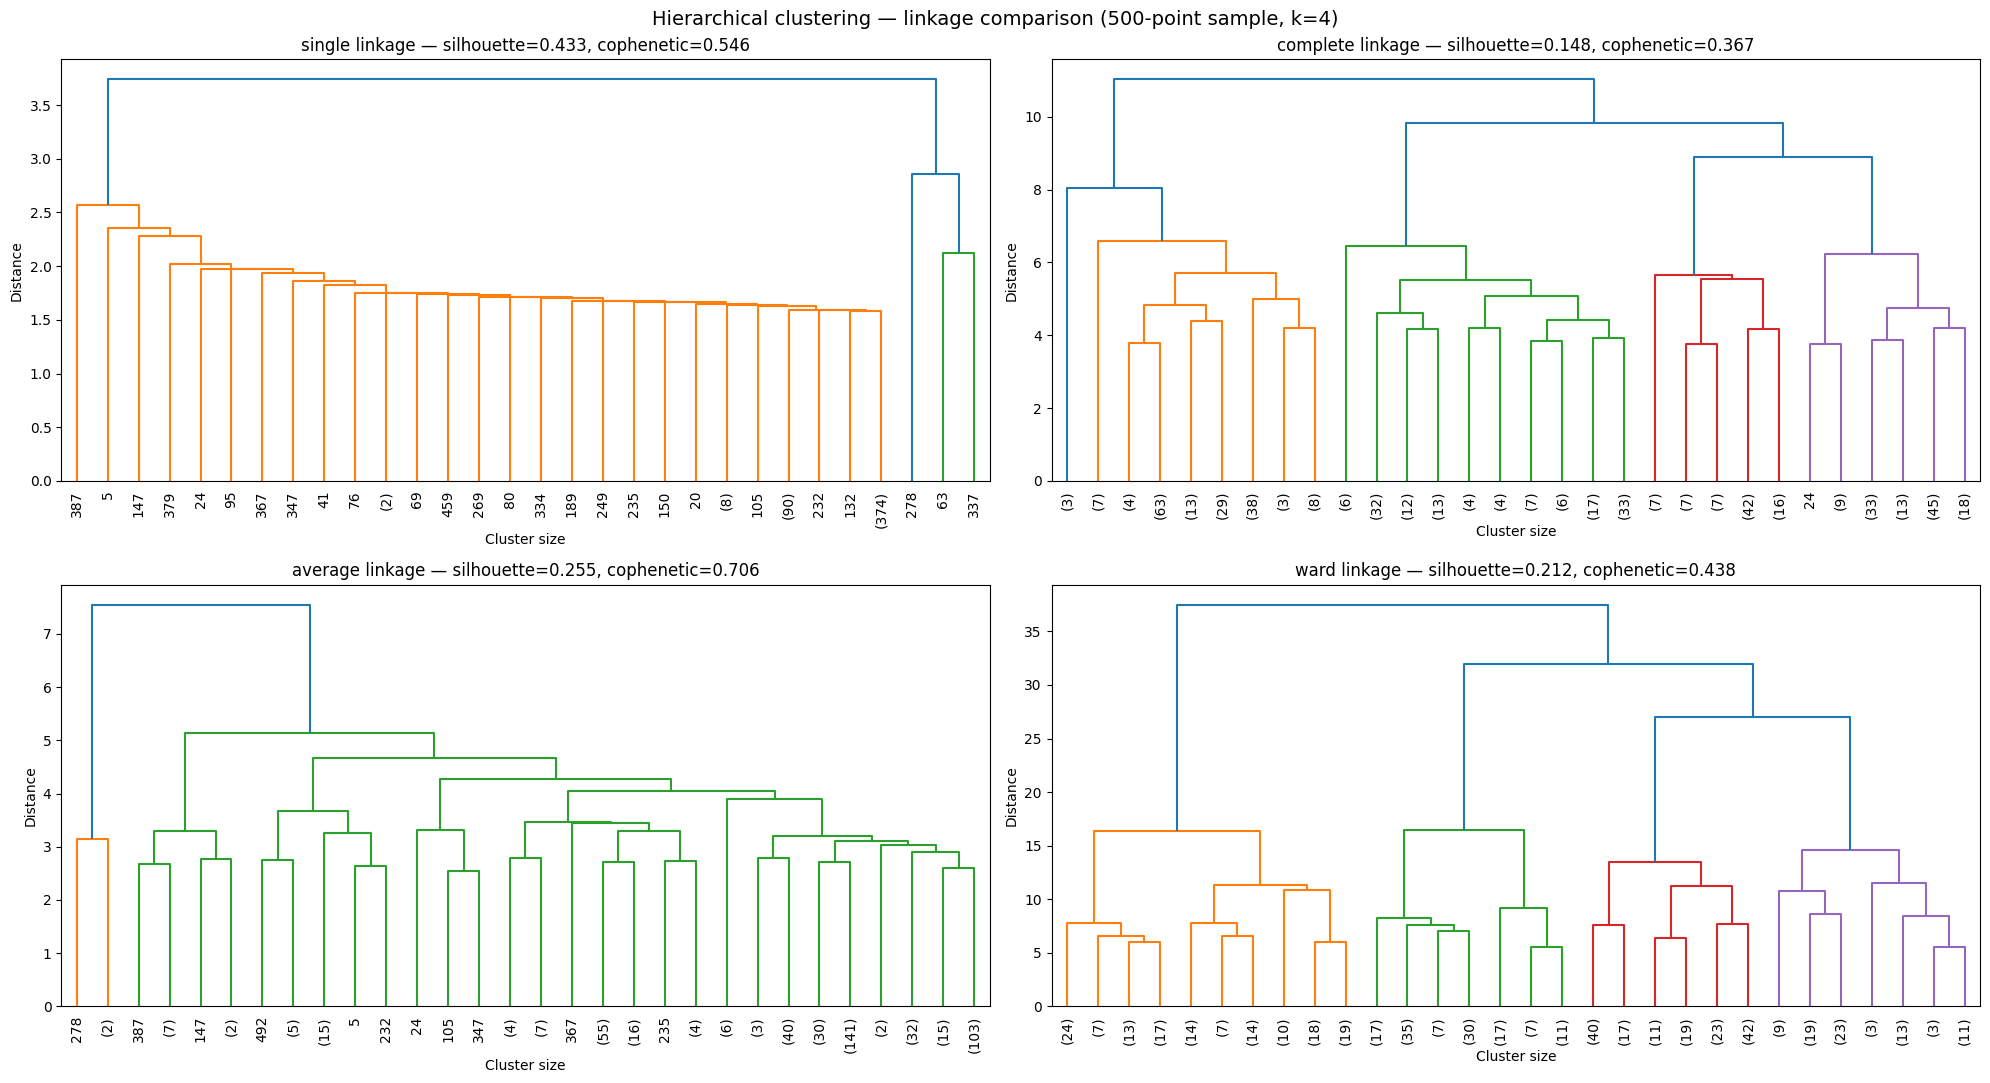

 linkage  silhouette (k=4)  cophenetic corr.  largest cluster %       cluster sizes
  single             0.433             0.546               99.2      [496, 1, 2, 1]
complete             0.148             0.367               33.6 [168, 134, 79, 119]
 average             0.255             0.706               92.6    [3, 11, 23, 463]
    ward             0.212             0.438               30.4 [143, 124, 152, 81]


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

# A 500-point sample: a dendrogram over 15,487 leaves is both slow to compute
# and visually unreadable.
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=500, replace=False)
X_sample = X_scaled[sample_idx]
D = pdist(X_sample)          # condensed distance matrix, reused for cophenetic corr.

methods = ["single", "complete", "average", "ward"]
hier_results, linkages = [], {}

fig, axes = plt.subplots(2, 2, figsize=(20, 11))
for ax, method in zip(axes.flatten(), methods):
    Z = linkage(X_sample, method=method, metric="euclidean")
    linkages[method] = Z

    dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, ax=ax)

    labels = fcluster(Z, t=4, criterion="maxclust")
    sizes = np.bincount(labels)[1:]
    sil = silhouette_score(X_sample, labels) if len(set(labels)) > 1 else np.nan
    coph, _ = cophenet(Z, D)   # how faithfully the tree preserves original distances

    hier_results.append({
        "linkage": method,
        "silhouette (k=4)": round(sil, 3),
        "cophenetic corr.": round(coph, 3),
        "largest cluster %": round(sizes.max() / sizes.sum() * 100, 1),
        "cluster sizes": list(sizes),
    })
    ax.set_title(f"{method} linkage — silhouette={sil:.3f}, cophenetic={coph:.3f}")
    ax.set_xlabel("Cluster size"); ax.set_ylabel("Distance")

plt.suptitle("Hierarchical clustering — linkage comparison (500-point sample, k=4)", fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/dendrograms_linkage_comparison.png', dpi=150)
plt.show()

print(pd.DataFrame(hier_results).to_string(index=False))

### Hierarchical clustering: linkage comparison

Four linkage criteria were compared on a random 500-point sample; a dendrogram
over 15,487 leaves is neither computationally practical nor visually readable.
Each tree was cut at k=4 for comparability with the K-Means solution and assessed
on three criteria: silhouette, cophenetic correlation (how faithfully the tree
preserves the original pairwise distances) and the size of the largest resulting
cluster.

| Linkage | Silhouette ↑ | Cophenetic ↑ | Largest cluster | Cluster sizes |
|---|---|---|---|---|
| single | **0.433** | 0.546 | 99.2% | 496, 1, 2, 1 |
| complete | 0.148 | 0.367 | 33.6% | 168, 134, 119, 79 |
| average | 0.255 | **0.706** | 92.6% | 463, 23, 11, 3 |
| ward | 0.212 | 0.438 | **30.4%** | 152, 143, 124, 81 |

The two highest silhouette scores belong to unusable partitions. Single linkage
scores 0.433 while placing 496 of 500 points in one cluster and isolating three
clusters of one, two and one point respectively. This is the textbook chaining
effect, and the dendrogram shows it directly: points attach one at a time at
nearly constant height, producing a staircase rather than a branching structure.
The score is high because singleton clusters are perfectly cohesive by
definition. Average linkage fails the same way less severely, with 92.6% of
points in one cluster.

Cophenetic correlation ranks the methods differently, and average linkage wins it
outright at 0.706 against Ward's 0.438. The two criteria measure different
things: cophenetic correlation asks how well the tree as a whole represents the
distance structure, while silhouette evaluates one particular horizontal cut
through it. Average linkage builds a faithful tree that happens to have no useful
four-way cut, since almost all of its merges occur in one branch. The
disagreement is informative rather than contradictory, and it is a reminder that
no single index settles the choice.

**Ward linkage was selected.** It is the only criterion producing a balanced
partition (largest cluster 30.4%, sizes 152/143/124/81), and its dendrogram shows
a genuine hierarchical structure: a top-level split at distance ≈37 into two
branches, the right one splitting again at ≈32 and ≈27. Complete linkage is the
nearest alternative but is worse on both other criteria. Ward's silhouette on
this sample (0.212) is not directly comparable to the K-Means figure computed on
the full dataset; the two are put on the same footing in the full-data comparison
below.

The pattern that recurs across all three algorithms in this module is worth
noting: the configurations scoring highest on silhouette — DBSCAN at eps=1.6
(0.523) and single linkage here (0.433) — are precisely those that isolate a
handful of points and leave everything else in one mass. On a dataset without
natural separation, silhouette rewards degeneracy, and cluster size distribution
is the more reliable guide.

Profiles (ward linkage, standardised):
         ComWeight  MinPlayers  MaxPlayers  ComAgeRec  NumOwned_log  \
cluster                                                               
1             1.08       -0.21       -0.39       0.99         -0.23   
2             0.02       -0.30       -0.03      -0.18          1.09   
3            -0.57       -0.33       -0.33      -0.67         -0.75   
4            -0.75        1.31        1.43      -0.27         -0.08   

         NumUserRatings_log  MfgPlaytime_log  
cluster                                       
1                     -0.35             1.05  
2                      1.14            -0.05  
3                     -0.66            -0.65  
4                     -0.03            -0.39  


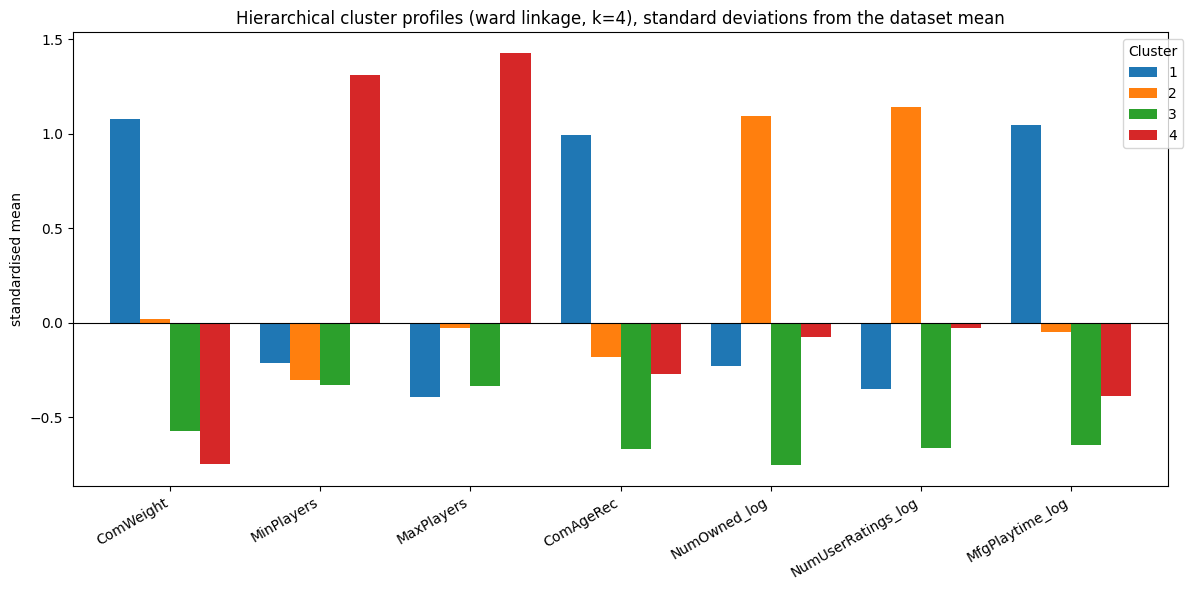

In [ ]:
BEST_LINKAGE = "ward"       # selected on the basis of the comparison table above

hier_labels = fcluster(linkages[BEST_LINKAGE], t=4, criterion="maxclust")

profile_hier = (pd.DataFrame(X_sample, columns=clustering_features)
                  .assign(cluster=hier_labels)
                  .groupby("cluster").mean())
print(f"Profiles ({BEST_LINKAGE} linkage, standardised):")
print(profile_hier.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
profile_hier.T.plot(kind="bar", ax=ax, width=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Hierarchical cluster profiles ({BEST_LINKAGE} linkage, k=4), "
             f"standard deviations from the dataset mean")
ax.set_ylabel("standardised mean")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/hierarchical_cluster_profiles.png', dpi=150)
plt.show()

### Hierarchical clustering: cluster interpretation

The Ward partition at k=4 recovers cluster profiles closely comparable to the
K-Means solution. Every cluster has a counterpart with the same defining
dimension:

| Ward | K-Means equivalent | Defining feature | Ward | K-Means |
|---|---|---|---|---|
| 1 | 2 — hobbyist strategy | `ComWeight` | +1.08 | +1.02 |
| | | `MfgPlaytime_log` | +1.05 | +1.03 |
| 2 | 3 — mainstream hits | `NumUserRatings_log` | +1.14 | +1.34 |
| 3 | 0 — casual short games | `ComWeight` | -0.57 | -0.68 |
| 4 | 1 — party games | `MinPlayers` | +1.31 | +1.61 |
| | | `MaxPlayers` | +1.43 | +1.41 |

Differences in the profile means fall within 0.1–0.3 standard deviations
throughout. This comparison operates at the level of cluster centroids, however,
and centroid agreement does not imply that the same individual games fall in the
same clusters. That question is addressed separately below, on the full dataset,
where the agreement proves considerably more qualified.

Hierarchical clustering contributes something the other two methods cannot — the
tree itself. The dendrogram shows that the top-level split at distance ≈37
separates party games (cluster 4) from everything else, meaning player-count
format, not complexity, is the deepest division in the data. Complexity separates
one level down, at ≈32, and popularity only at ≈27. This ordering is invisible in
a flat partition, and it independently justifies the choice of K=4 over K=3 made
earlier: the party-game branch is the first split the data offers, so a solution
omitting it discards the most prominent structure present.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Ward on the full dataset, without a connectivity constraint, computes the
# complete pairwise distance matrix: ~1.2 GB at n = 15,487. If the runtime
# crashes, fall back to the 500-point sample result and report the two
# silhouette values as not directly comparable.
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
hier_labels_full = agg.fit_predict(X_scaled)

sizes_h = np.bincount(hier_labels_full)
print("Ward on full data — cluster sizes:", sizes_h,
      f"(largest = {sizes_h.max()/len(hier_labels_full)*100:.1f}%)")
print("Silhouette (Ward, full data, k=4):",
      round(silhouette_score(X_scaled, hier_labels_full), 4))
print("Silhouette (K-Means, K=4, for reference):",
      round(silhouette_score(X_scaled, cluster_labels), 4))

print("\nAgreement between Ward and K-Means partitions:")
print("  Adjusted Rand Index:  ", round(adjusted_rand_score(cluster_labels, hier_labels_full), 3))
print("  Normalised Mutual Info:", round(normalized_mutual_info_score(cluster_labels, hier_labels_full), 3))

print("\nContingency table (rows = K-Means, columns = Ward):")
print(pd.crosstab(pd.Series(cluster_labels, name="kmeans"),
                  pd.Series(hier_labels_full, name="ward")))

Ward on full data — cluster sizes: [5339 1760 4550 3838] (largest = 34.5%)
Silhouette (Ward, full data, k=4): 0.1763
Silhouette (K-Means, K=4, for reference): 0.2452

Agreement between Ward and K-Means partitions:
  Adjusted Rand Index:   0.462
  Normalised Mutual Info: 0.492

Contingency table (rows = K-Means, columns = Ward):
ward       0     1     2     3
kmeans                        
0        812   217  1024  3725
1        262  1507   130     0
2        764     9  3224    52
3       3501    27   172    61


### Agreement between Ward and K-Means on the full dataset

The comparison above rests on a 500-point sample, so Ward was additionally run on
all 15,487 games to obtain directly comparable figures:

| | Sizes | Largest | Silhouette |
|---|---|---|---|
| K-Means, K=4 | 5778 / 4049 / 3761 / 1899 | 37.3% | 0.245 |
| Ward, k=4 | 5339 / 4550 / 3838 / 1760 | 34.5% | 0.176 |

Adjusted Rand Index: **0.462**. Normalised Mutual Information: **0.492**.

The agreement is moderate rather than close, and the contingency table shows the
disagreement is not uniform across clusters. Two correspond tightly: 93% of the
mainstream-hits cluster and 79% of the party-games cluster fall into a single
Ward group each. The other two blur — of the casual-games cluster, 64% maps to
one Ward group while the remaining third splits between two others, and the
hobbyist cluster loses 764 games to the mainstream branch.

This is a more informative result than the centroid comparison suggested. The two
extremes of the data are stable: party games are separated by player count,
mainstream hits by an order-of-magnitude gap in rating counts, and both
boundaries survive a change of algorithm. The interior of the complexity
continuum does not. Games of middling difficulty have no natural allegiance to
either the casual or the hobbyist group, and where the boundary falls depends on
whether variance is minimised globally, as K-Means does by reassigning points
until convergence, or locally through a sequence of irreversible merges, as Ward
does.

Ward also scores lower on the full data (0.176 against 0.245). Its greedy
agglomerative procedure cannot revise an early merge; on a continuum with no
sharp boundaries this limitation is more consequential than it would be on
well-separated data.

The finding qualifies rather than undermines the K-Means result. The clusters
that matter most for interpretation are robust, and the algorithms agree on the
broad structure of the space. But the partition is one reasonable division of a
continuum rather than a recovery of pre-existing groups, and the roughly one
third of games that change cluster under a change of algorithm is the honest
measure of that.

## 5. Final discussion — which algorithm suits this dataset

### Summary of results

| Algorithm | Configuration | Silhouette | Clusters | Largest cluster | Interpretable? |
|---|---|---|---|---|---|
| K-Means | K=4 | 0.245 | 4 | 37.3% | yes |
| DBSCAN | eps=1.0, min_samples=20 | 0.101 | 3 (+7.7% noise) | 72.2% | no |
| Hierarchical | Ward, k=4 | 0.176 | 4 | 34.5% | yes |

All three figures are computed on the full dataset of 15,487 games and are
therefore directly comparable.

**K-Means (K=4) is the recommended algorithm.** It attains the highest silhouette
among non-degenerate configurations, produces four groups of comparable size, and
its clusters map onto categories a domain expert would recognise: casual short
games, party games, hobbyist strategy games, and mainstream hits. Board game
attributes are continuous and roughly convex in the feature space, which is the
situation K-Means is designed for.

Two further results bear on the choice. Ward linkage produces cluster centroids
closely comparable to the K-Means ones, though the two partitions agree only
moderately at the level of individual games (ARI = 0.462): the extremes of the
data are stable while the interior of the complexity continuum is not. And the
Ward dendrogram shows that the deepest split in the data separates party games
from everything else, confirming that the player-count dimension is genuine
structure rather than the marginal refinement its silhouette cost had suggested.

**DBSCAN is not suited to this dataset**, and the reason is informative. It
partitioned the games on `MinPlayers` alone — three clusters with values of
exactly 2.0, 3.0 and 1.0, and near-identical means on all six remaining
variables. A low-cardinality integer variable becomes, after standardisation, a
set of parallel hyperplanes separated by empty space, and density-based
clustering cuts precisely at such gaps. Those gaps are more pronounced than any
density variation among the continuous attributes, so they dominate. The
algorithm's core assumption — that meaningful groups are dense regions separated
by sparse ones — does not hold for data where every attribute varies smoothly.

### What the metrics could not decide

Three times in this module the highest silhouette score belonged to a partition
that was unusable:

| Configuration | Silhouette | What it actually produced |
|---|---|---|
| DBSCAN, eps=1.6, min_samples=5 | 0.523 | 99.9% of points in one cluster |
| Single linkage, k=4 | 0.433 | clusters of 496, 2, 1 and 1 points |
| Average linkage, k=4 | 0.255 | 92.6% of points in one cluster |

Each scores well by isolating a handful of points far from the mass, since
singleton and near-singleton clusters are perfectly cohesive by construction. On
data without natural separation, silhouette rewards degeneracy. Cluster size
distribution proved the more reliable guide throughout, and the two indices added
for the K=3 versus K=4 decision — Calinski-Harabasz and Davies-Bouldin — did not
resolve it either, since both favoured the solution that ignored an entire
dimension of the data.

This is the methodological finding of the module: on a continuous dataset with no
sharp boundaries, internal validation indices are necessary but not sufficient.
Selection required examining what each partition actually contained.

### Limitations

Silhouette values of 0.18–0.25 indicate moderate rather than strong separation.
The clusters describe regions of a continuum, not discrete well-isolated groups,
and the boundaries between them are to some degree a modelling choice. This is a
property of the data — complexity, playtime and popularity have no natural
breakpoints — rather than a shortcoming of the analysis, but it means the
partition should be read as a useful summary of the space rather than as a
discovery of pre-existing categories.

The moderate Ward–K-Means agreement quantifies this directly. Roughly a third of
games change cluster under a change of algorithm, concentrated in the middle of
the complexity range, while the party-game and mainstream-hit boundaries hold at
79% and 93% respectively. The result is honest about which parts of the partition
can be relied upon and which are the algorithm's choice.

Listwise deletion removed 26.9% of the games, concentrated in older and
rarely-voted-on titles. The clusters therefore describe the community-assessed
portion of the catalogue; games the community has never rated are absent from the
analysis by construction.

The dendrograms rest on a 500-point sample, and a different draw would produce
somewhat different sizes and cophenetic values. The Ward partition itself was
recomputed on the full dataset, so the comparison figures reported above do not
depend on the sample.

### Contribution of each method

The three algorithms proved useful in different ways rather than being ranked on
a single scale. K-Means produced the partition reported as the result.
Hierarchical clustering supplied two things a flat partition cannot: the ordering
of the splits, which independently justified K=4, and a quantitative measure of
how much of that partition survives a change of method. DBSCAN produced no usable
clustering, but in an earlier run it isolated the `MfgPlaytime = 0` sentinel that
univariate outlier analysis had missed — a finding fed back into Module 1, after
which the correlation between complexity and playtime rose from r = 0.18 to
r = 0.72. On data of this kind, density-based methods are better employed as a
diagnostic for encoding artefacts and discreteness than as a clustering tool.